# Synthetic Generation using Diffusion with a Conditional and a Cosine schedule
To see how a diffusion model canbe trained to create synthetic data, we generate a two dimensional dataset that has 8 disk like clusters around a circle centered at the origin. We will then train a diffusion to be able to generate synthetic data but use the labels and centers as a conditional. Instead of a linear schedule, we demonstrate here how a cosine schedule would work.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from synthetic_generation.diffusion.models import DiffusionNet
from synthetic_generation.diffusion.process import DiffusionProcess
from synthetic_generation.diffusion.schedules import cosine_beta_schedule

In [2]:
def make_gaussian_mixture(
    n_samples=50_000,
    centers=8,
    radius=5.0,
    std=0.5,
    seed=0
):
    """
    Parameters
    ----------
    n_samples : int
        number of samples
    centers : int 
        number of disk clusters
    radius : float
        radius of ring containing centers of the clusters
    std : float
        standard deviation for distance from center of disk for a point
    seed : int
        random seed to use
    Returns
    -------
    tuple
        array of sample points, array of cluster centers for each point, array of labels for each cluster
    """
    rng = np.random.default_rng(seed)
    # compute the centers of each cluster
    angles = np.linspace(0, 2*np.pi, centers, endpoint=False)
    means = np.stack([
        radius * np.cos(angles),
        radius * np.sin(angles)
    ], axis=1)

    samples = []
    sample_labels = []
    sample_centers = []
    # choose a random center and a random point in the cluster
    for _ in range(n_samples):
        k = rng.integers(0, centers)
        # add the center and label
        sample_labels.append(k)
        sample_centers.append(means[k])
        x = rng.normal(loc=means[k], scale=std, size=2)
        samples.append(x)

    return np.array(samples, dtype=np.float32), np.array(sample_labels), np.array(sample_centers,dtype=np.float32)

In [3]:
X_gauss, labels, centers = make_gaussian_mixture()

In [4]:
# make the conditional
one_hot_labels = F.one_hot(torch.tensor(labels)).float()
c = torch.cat([torch.Tensor(centers), one_hot_labels], dim=1)

#### Training the model
We create a simple DiffusionNet model and then use the DiffusionProcess with that model to train on the data along with the conditional

In [5]:
DenoiseNet = DiffusionNet(
    data_dim=2,
    conditional_dim=10,
    num_hidden_layers=4, 
    hidden_dims=(256,256)
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DenoiseNet.to(device)

In [6]:
# turn the data into a tensor and move to device
X_train = torch.Tensor(X_gauss).to(device)
c=c.to(device)

In [7]:
diffusion_process = DiffusionProcess(
    model = model,
    num_timesteps = model.time_embedding.num_timesteps,
    betas=cosine_beta_schedule(num_timesteps=model.time_embedding.num_timesteps)
)

In [8]:
diffusion_process.train(
    X=X_train,
    c=c
)

Diffusion training:   0%|          | 0/100 [00:00<?, ?it/s]

#### Visualization
We now create synthetic data from the process and look at a scatterplot to compare it to the real data.

In [9]:
sample_size = 10000
idx = np.random.default_rng(42).choice(len(X_gauss), size=sample_size, replace=False)
X_sample = X_gauss[idx]
c_sample = c[idx]

In [10]:
X_fake = diffusion_process.generate_samples(num_samples=sample_size, c=c_sample)

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Since we used a conditional, we'll color each point in the true and generated data based on the label

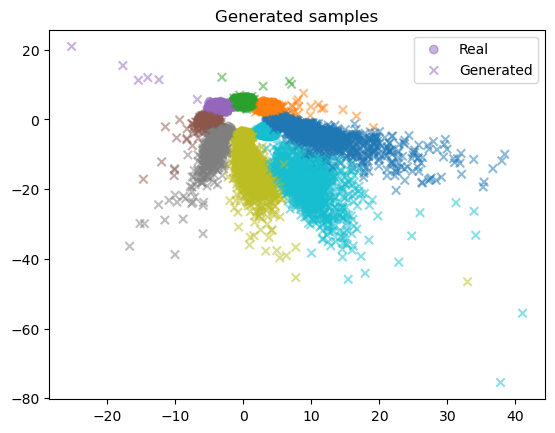

In [11]:
label_sample = labels[idx]
plt.scatter(X_sample[:, 0], X_sample[:, 1], alpha=0.5, c=label_sample, cmap='tab10')
plt.scatter(X_fake[:, 0], X_fake[:, 1], alpha=0.5, c=label_sample, cmap='tab10', marker='x')
plt.legend(["Real","Generated"])
plt.title("Generated samples")
plt.show()

We can see here that for this dataset, the cosine schedule performs far worse, with the clusters generated having much larger variance than the true data. We can try using DDIM as well. As DDIM sometimes creates outliers even with a linear schedule, this doesn't suggest we will get an improvement.

In [12]:
X_fake_ddim = diffusion_process.generate_samples_ddim(
    num_samples=sample_size,
    c=c_sample,
    num_inference_steps=50,
    )

DDIM Sampling (50 steps):   0%|          | 0/50 [00:00<?, ?it/s]

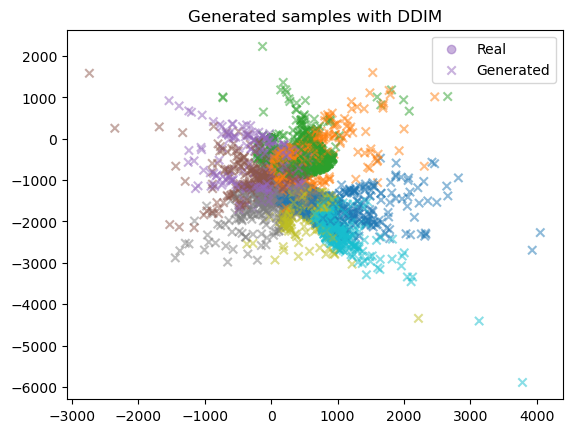

In [13]:

plt.scatter(X_sample[:, 0], X_sample[:, 1], alpha=0.5, c=label_sample, cmap='tab10')
plt.scatter(X_fake_ddim[:, 0], X_fake_ddim[:, 1], alpha=0.5, c=label_sample, cmap='tab10', marker='x')
plt.legend(["Real","Generated"])
plt.title("Generated samples with DDIM")
plt.show()

#### Fixing the 'explosion' problems with the cosine schedule
We can see that our generated data has extremely high radial variance within each cluster. The problem is that we did not scale the data. We will go through the same process as above , but use a scaler and see how that improves results.

In [14]:
# get scaled version of data including centers
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_gauss)
centers_scaled = scaler.transform(centers)

In [15]:
# for consistency we use the scaled centers in the conditional
# make the conditional
one_hot_labels = F.one_hot(torch.tensor(labels)).float()
c_scaled = torch.cat([torch.Tensor(centers_scaled), one_hot_labels], dim=1)

In [16]:
torch.manual_seed(42) # reseed for the comparison

In [17]:
DenoiseNet_scaled = DiffusionNet(
    data_dim=2,
    conditional_dim=10,
    num_hidden_layers=4, 
    hidden_dims=(256,256)
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DenoiseNet_scaled.to(device)

In [18]:
diffusion_process = DiffusionProcess(
    model = model,
    num_timesteps = model.time_embedding.num_timesteps,
    betas=cosine_beta_schedule(num_timesteps=model.time_embedding.num_timesteps)
)

In [19]:
X_train_scaled = torch.Tensor(X_scaled).to(device)
diffusion_process.train(
    X=X_train_scaled,
    c=c_scaled
)

Diffusion training:   0%|          | 0/100 [00:00<?, ?it/s]

In [20]:
# get the sample from our scaled c
c_scaled_sample = c_scaled[idx]
X_scaled_fake = diffusion_process.generate_samples(num_samples=sample_size, c=c_scaled_sample)

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

In [21]:
# get the unscaled fake data
X_scaled_fake_np =X_scaled_fake.detach().cpu().numpy()
X_gen = scaler.inverse_transform(X_scaled_fake_np)

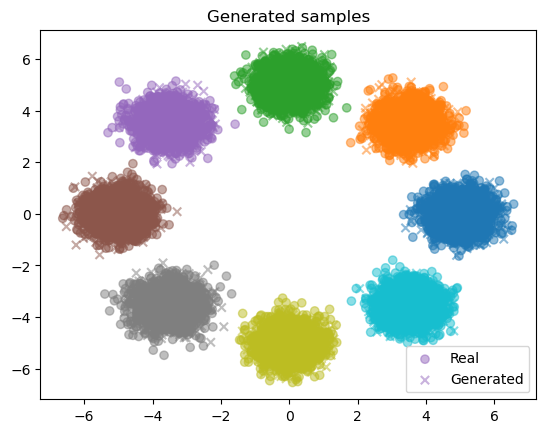

In [22]:
label_sample = labels[idx]
plt.scatter(X_sample[:, 0], X_sample[:, 1], alpha=0.5, c=label_sample, cmap='tab10')
plt.scatter(X_gen[:, 0], X_gen[:, 1], alpha=0.5, c=label_sample, cmap='tab10', marker='x')
plt.legend(["Real","Generated"])
plt.title("Generated samples")
plt.show()

### Conclusions

Unlike the linear schedule, which worked reasonably well with unscaled data, the cosine beta schedule produced generated samples far from the true data when trained on unscaled inputs. This behavior is driven by the high values of beta near the end of the cosine schedule, which make the reverse diffusion process extremely sensitive during generation.

Once the data was scaled (we used `StandardScaler`, though scaling to $[-1,1]$ would also work), the cosine schedule not only produced clean and accurate samples, but also achieved lower training loss, indicating a better-conditioned and more stable denoising task